# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [6]:
data1 = "C:/Users/Karina/Downloads/House_Rent_Dataset.csv"
df = pd.read_csv(data1)

In [7]:
df.shape

(4746, 12)

In [8]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [10]:
missing_values = df.isnull().sum()
miss_val_pers = (missing_values/len(df)) * 100
print(missing_values)
print(miss_val_pers)

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64
Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64


In [11]:
baz_stat = df[['Rent', 'Size']].describe()
baz_stat.round(2)

,Rent,Size
count,4746.00,4746.00
mean,34993.45,967.49
std,78106.41,634.20
min,1200.00,10.00
25%,10000.00,550.00
50%,16000.00,850.00
75%,33000.00,1200.00
max,3500000.00,8000.00


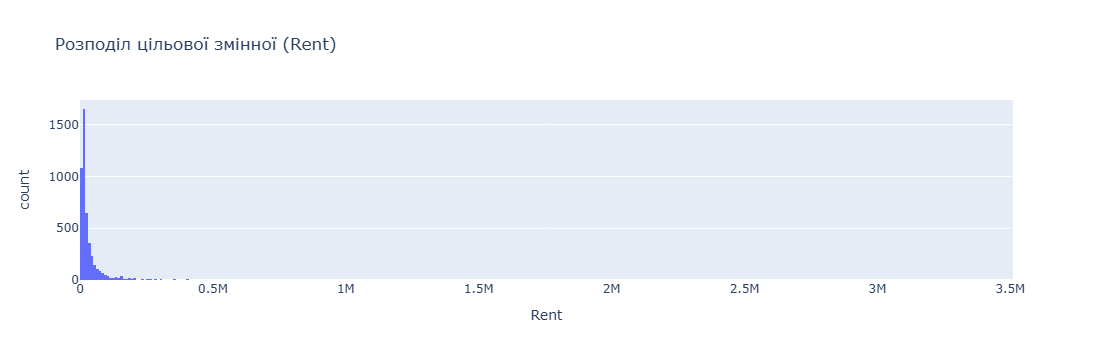

In [12]:
fig = px.histogram(
    df,
    x = 'Rent',
    title = 'Розподіл цільової змінної (Rent)'
)
fig.show()

In [13]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

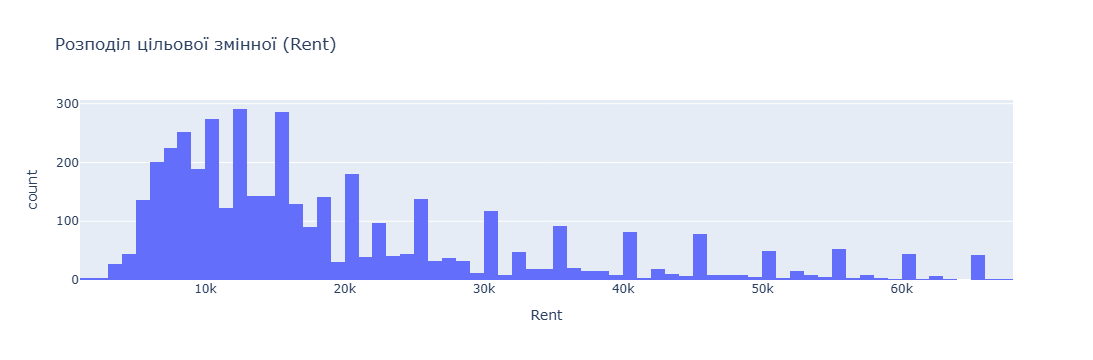

In [14]:
fig = px.histogram(
    df_cleaned,
    x = 'Rent',
    title = 'Розподіл цільової змінної (Rent)'
)
fig.show()

In [15]:
unic_cat = df[['BHK', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']].nunique()
unic_cat

BHK                     6
Floor                 480
Area Type               3
Area Locality        2235
City                    6
Furnishing Status       3
Tenant Preferred        3
Bathroom                8
Point of Contact        3
dtype: int64

In [16]:
df['Floor'].unique()

<StringArray>
[ 'Ground out of 2',       '1 out of 3',       '1 out of 2',
  'Ground out of 1',  'Ground out of 4',       '1 out of 4',
       '1 out of 1',  'Ground out of 3',       '2 out of 3',
       '4 out of 5',
 ...
      '4 out of 26',     '24 out of 33',      '4 out of 17',
      '1 out of 35',     '11 out of 35', 'Ground out of 15',
 'Ground out of 27',     '15 out of 30',     '12 out of 30',
     '23 out of 34']
Length: 480, dtype: str

Остаточні категоріальні колонки:

In [17]:
unic_cat = df[['BHK', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']].nunique()
unic_cat

BHK                  6
Area Type            3
City                 6
Furnishing Status    3
Tenant Preferred     3
Bathroom             8
Point of Contact     3
dtype: int64


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


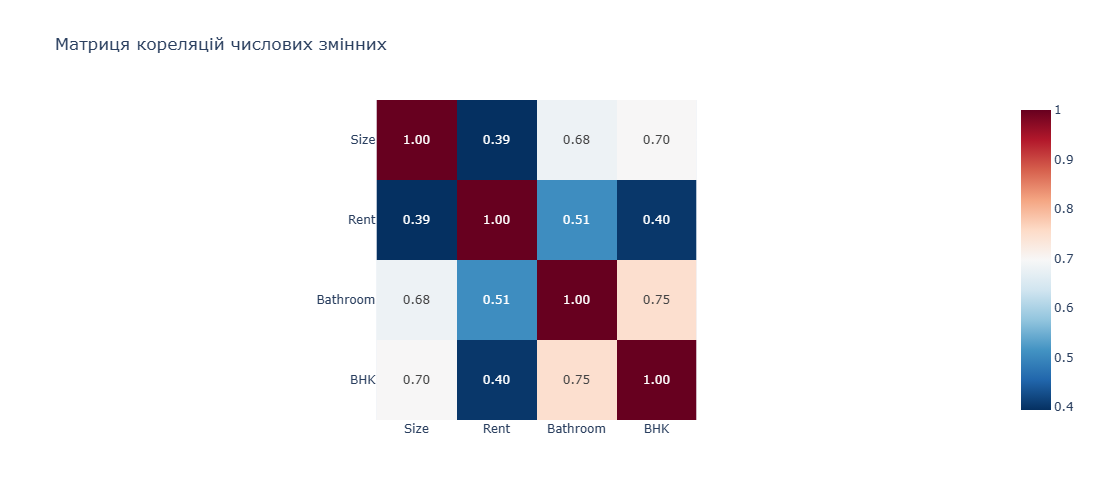

In [18]:
metrics_df = df_cleaned[['Size', 'Rent', 'Bathroom', 'BHK']]
correlation_matrics = metrics_df.corr()
fig = px.imshow(
    correlation_matrics,
    title = 'Матриця кореляцій числових змінних',
    color_continuous_scale = 'RdBu_r',
    text_auto = '.2f'
)
fig.update_layout(height = 500)
fig.show()

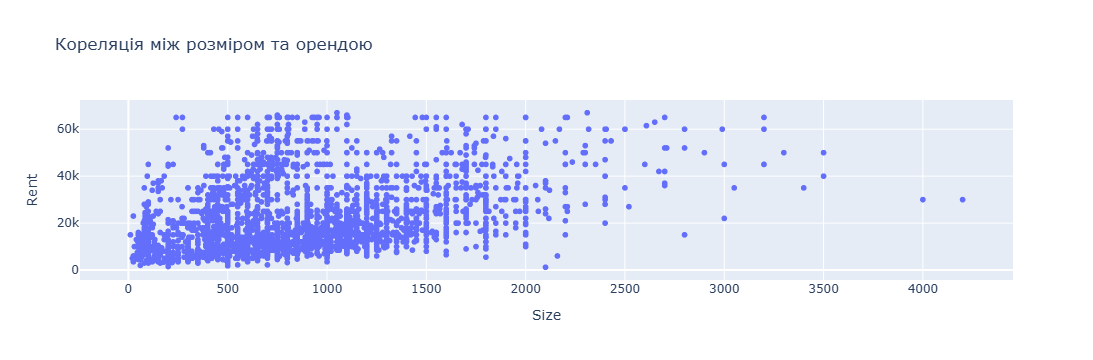

In [19]:
fig = px.scatter(
    df_cleaned,
    x = 'Size',
    y = 'Rent',
    title = 'Кореляція між розміром та орендою'
)
fig.show()

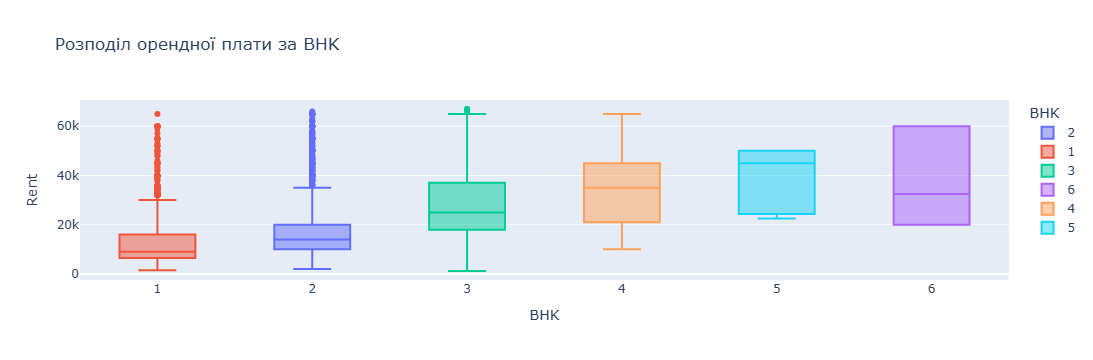

In [20]:
fig = px.box(
    df_cleaned,
    x='BHK', 
    y='Rent', 
    color='BHK',
    title='Розподіл орендної плати за BHK')
fig.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [21]:
dummies_list = [
pd.get_dummies(df_cleaned['BHK'], prefix='BHK').astype(int),
pd.get_dummies(df_cleaned['Area Type'], prefix='Area Type').astype(int),
pd.get_dummies(df_cleaned['City'], prefix='City').astype(int),
pd.get_dummies(df_cleaned['Furnishing Status'], prefix='Furn Status').astype(int),
pd.get_dummies(df_cleaned['Tenant Preferred'], prefix='Ten Pref').astype(int),
pd.get_dummies(df_cleaned['Bathroom'], prefix='Bathroom').astype(int),
pd.get_dummies(df_cleaned['Point of Contact'], prefix='PoC').astype(int)
]

df_cleaned = pd.concat([df_cleaned] + dummies_list, axis = 1)

df_cleaned.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,...,Bathroom_1,Bathroom_2,Bathroom_3,Bathroom_4,Bathroom_5,Bathroom_6,Bathroom_7,PoC_Contact Agent,PoC_Contact Builder,PoC_Contact Owner
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,...,0,1,0,0,0,0,0,0,0,1
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,...,1,0,0,0,0,0,0,0,0,1
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,...,1,0,0,0,0,0,0,0,0,1
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,...,1,0,0,0,0,0,0,0,0,1
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,...,1,0,0,0,0,0,0,0,0,1


In [22]:
df_cleaned['Rent_per_Size'] = df_cleaned['Rent'] / df_cleaned['Size']
df_cleaned['Area_per_Room'] = df_cleaned['Size'] / df_cleaned['BHK']

In [23]:
df_cleaned.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact', 'BHK_1', 'BHK_2', 'BHK_3', 'BHK_4',
       'BHK_5', 'BHK_6', 'Area Type_Built Area', 'Area Type_Carpet Area',
       'Area Type_Super Area', 'City_Bangalore', 'City_Chennai', 'City_Delhi',
       'City_Hyderabad', 'City_Kolkata', 'City_Mumbai',
       'Furn Status_Furnished', 'Furn Status_Semi-Furnished',
       'Furn Status_Unfurnished', 'Ten Pref_Bachelors',
       'Ten Pref_Bachelors/Family', 'Ten Pref_Family', 'Bathroom_1',
       'Bathroom_2', 'Bathroom_3', 'Bathroom_4', 'Bathroom_5', 'Bathroom_6',
       'Bathroom_7', 'PoC_Contact Agent', 'PoC_Contact Builder',
       'PoC_Contact Owner', 'Rent_per_Size', 'Area_per_Room'],
      dtype='str')

In [24]:
x = df_cleaned.drop(columns = ['Rent', 'Posted On', 'Area Locality', 'Floor', 'Rent_per_Size',
                             'BHK', 'Area Type', 'City', 'Furnishing Status', 
                             'Tenant Preferred', 'Bathroom', 'Point of Contact'])
y = df_cleaned['Rent']

In [25]:
%%capture
!pip install scikit-learn 
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled_df, y,
    test_size=0.2,  
    random_state=42 
)

In [28]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
weights = pd.DataFrame({
    'Feature': x.columns,
    'Weight': model.coef_
})
weights['Abs_Weight'] = weights['Weight'].abs()
top_10 = weights.sort_values(by='Abs_Weight', ascending=False).head(10)

print("ТОП-10 ознак, що найбільше впливають на ціну:")
print(top_10[['Feature', 'Weight']])

ТОП-10 ознак, що найбільше впливають на ціну:
              Feature       Weight
15        City_Mumbai  5920.996533
0                Size  3560.081200
29  PoC_Contact Agent  1847.116183
31  PoC_Contact Owner -1845.684892
13     City_Hyderabad -1737.852484
14       City_Kolkata -1728.671879
1               BHK_1 -1717.547295
3               BHK_3  1584.910344
24         Bathroom_3  1482.272434
11       City_Chennai -1227.783248


In [30]:
x = x.loc[:, ~x.columns.duplicated()]

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Виникли проблеми, бо декілька разів конкатинувала dummies🙃

In [31]:
x = x.loc[:, ~x.columns.duplicated()]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

weights = pd.DataFrame({
    'Feature': x.columns,
    'Weight': model.coef_
})
print(weights.sort_values(by='Weight', ascending=False).head(5))

        Feature        Weight
15  City_Mumbai  16526.496111
5         BHK_5   8612.213126
28   Bathroom_7   6887.911304
26   Bathroom_5   5800.043038
4         BHK_4   5187.582251


Найбільше впливає місто та кількість кімнат.

In [32]:
y_train_pred = model.predict(x_train)

y_test_pred = model.predict(x_test)

comparison = pd.DataFrame({
    'Реальна оренда': y_test.values[:10],
    'Прогнозована оренда': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})
print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна оренда  Прогнозована оренда  Помилка
0           22000              27587.0  -5587.0
1            5000               3664.0   1336.0
2           37000              41662.0  -4662.0
3            8000               3209.0   4791.0
4           15000              14793.0    207.0
5           20000              23583.0  -3583.0
6            8500              17760.0  -9260.0
7            7000               4194.0   2806.0
8            3000                236.0   2764.0
9            8000               6223.0   1777.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: Оренда: {mae:.2f}")
print(f"RMSE: Оренда: {rmse:.2f}")
print(f"R²: {r2:.3f}")

mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: Оренда: {mae:.2f}")
print(f"RMSE: Оренда: {rmse:.2f}")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: Оренда: 5561.70
RMSE: Оренда: 7891.08
R²: 0.675
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: Оренда: 5480.04
RMSE: Оренда: 7621.41
R²: 0.696


Маемо гідний коефіціент детермінації, що свідчить що модель вже видає непогані результати. Ознак перенавчання, або недонавчання не бачу, оскільки різниці майже нема між тренувальними даними та тестовими.

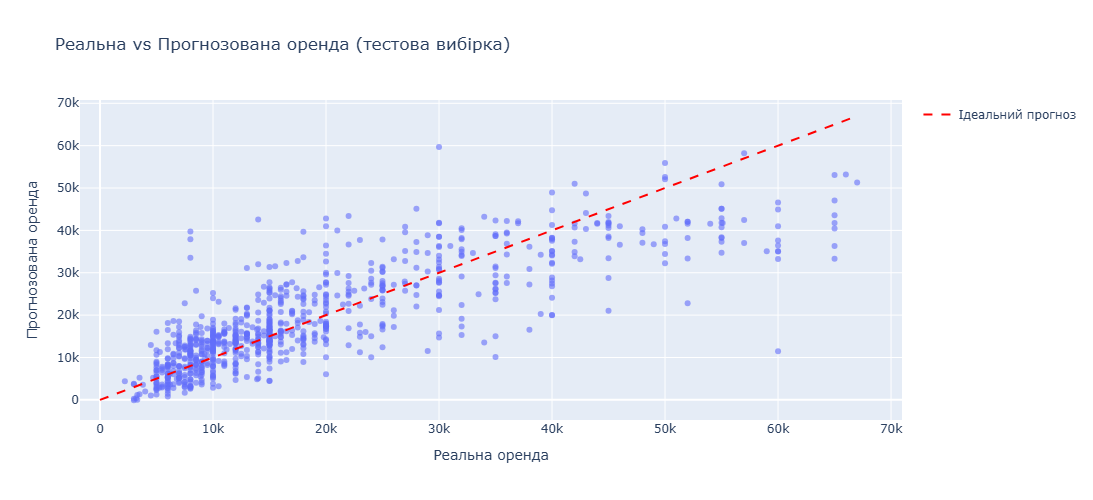

In [34]:
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальна vs Прогнозована оренда (тестова вибірка)',
    labels={'x': 'Реальна оренда', 'y': 'Прогнозована оренда'},
    opacity=0.6
)

max_val = max(y_test.max(), y_test_pred.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [35]:
residuals = y_test - y_test_pred
residuals

1998   -5586.681328
3190    1336.372672
2670   -4662.221531
4647    4791.082188
4488     207.303661
           ...     
1137    1701.391455
80     -8422.131865
258    -5715.757202
296     1339.818033
1978    3648.771818
Name: Rent, Length: 846, dtype: float64

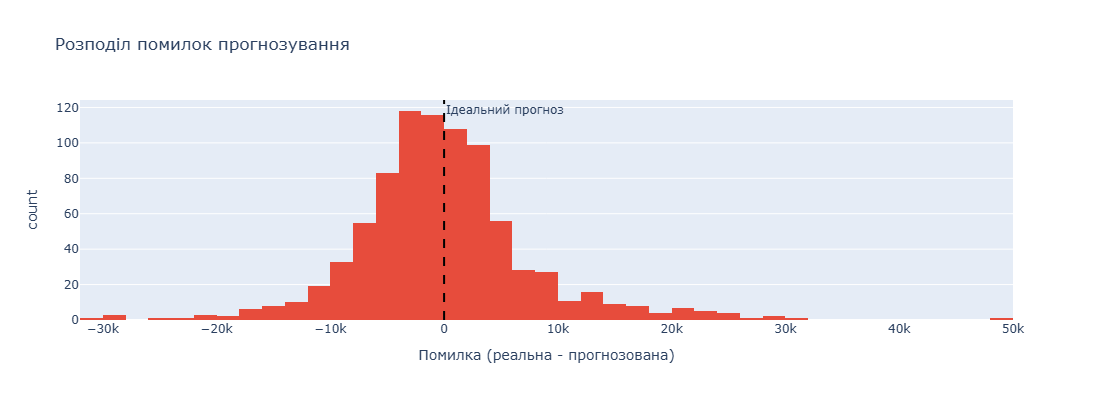

In [36]:
fig = px.histogram(
    x = residuals,
    nbins = 50,
    title = 'Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальна - прогнозована)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

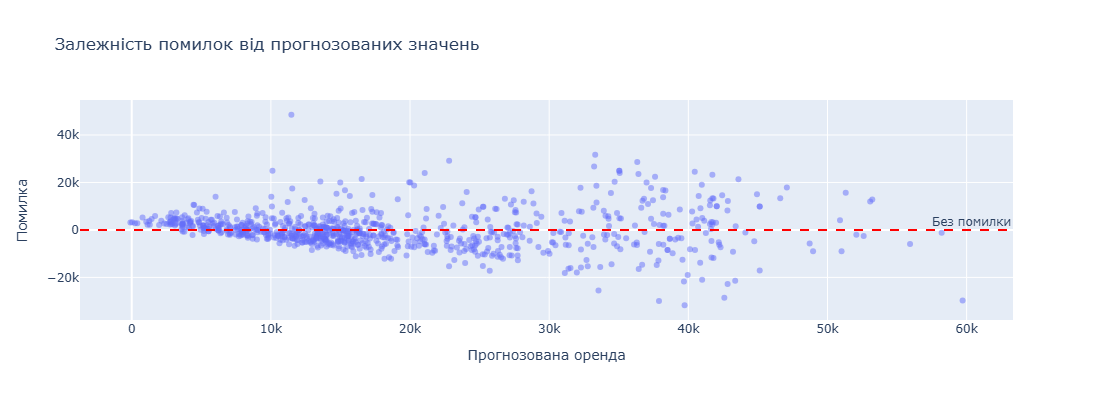

In [37]:
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованих значень',
    labels={'x': 'Прогнозована оренда', 'y': 'Помилка'},
    opacity=0.5
)

fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=400)
fig.show()

In [40]:
errors_df = pd.DataFrame({
    'real': y_test.values,
    'predicted': y_test_pred,
    'error': np.abs(residuals)
})

top_errors = errors_df.nlargest(5, 'error')
print("Прогнози з найбільшими помилками прогнозування:")
print(top_errors)

Прогнози з найбільшими помилками прогнозування:
       real     predicted         error
3584  60000  11473.591443  48526.408557
549    8000  39732.776367  31732.776367
3962  65000  33306.764429  31693.235571
904    8000  37890.404736  29890.404736
275   30000  59708.610718  29708.610718


Судячи з графіків - модель найбільше помиляеться в дорогому сегменті, з 20 тисяч і особливо з 30 починаються сильні розбіжності. Скоріше за все модель Недооцінює вплив міста. 

Можливо мало б сенс окремо розраховувати якісь дорогі міста типу Мумбаїв. Також може модель краще б працювала на Decision Tree.